## RDUH P2 Pathway Planner

This model aims to test a new intervention for P2 beds
The model runs in days
This model includes sensitivity to acute delay on downstream LoS  

**BASE:** This is the current set-up  

Spot: share 0.7, LOS 56 days, beds 242
Block: share 0.3, LOS 46 days, beds 85

**PROPOSED:** This is the proposed set-up  

Spot: share 0.2, LOS 56 days, beds 69
Non RDUH Block: share 0.5, LOS 46 days, beds 135
RDUH Block: share 0.3, LOS 24 days, beds 54

> NOTE that the proposed scenario here includes 6 more beds (informed by previous model) and a delay parameter to account for deconditioning.

## Deconditioning assumptions

Hospitial-associated deconditioning refers to declines in physical, cognitive, and functional capacity that occur secondary to hospitalisation, primarily due to inactivity. Patients may spend as little as 7 minutes per day walking while in hospital. Those waiting for a downstream bed are particularly at risk as they are deprioritised for rehabilitation. 

> Görgülü B, Dong J, Hunter K, Bettio KM, Vukusic B, Ranisau J, Spencer G, Tang T, Sarhangian V. Association Between Delayed Discharge From Acute Care and Rehabilitation Outcomes and Length of Stay: A Retrospective Cohort Study. Arch Phys Med Rehabil. 2023 Jan;104(1):43-51. doi: 10.1016/j.apmr.2022.05.017. Epub 2022 Jun 26. PMID: 35760110.

This paper reports that for *medical* patients, each additional day of delayed discharge from acute to rehab was associated wtih a 5.1% increase in rehabilitation LoS and an 0.08% reduction in rehabilitation efficiency.
For *neuro/muscukoskeletal* patients, each additional day of delay was associated with an 11.6% increase in rehabilitation LoS. 

#### The simplest meaningful adaptation is to replace the fixed LOS sample with a function that conditions LOS on waiting time

**Limitation:** This is a heuristic approximation that hard-codes a linear delay-LOS relationship. The true relationship may be non-linear, frailty-dependent, and context-specific. 
Therefore the SCOPE approach offers a more principled treatment.

### Assumptions:

Exponential inter-arrival times;
Lognormal service times

We don't have stdev, so we will assume a CV (coefficient of variation) such that sd = CV * mean and set to 0.2. Sensitivity to CV can be done.

In [1]:
import simpy
import numpy as np
import copy
import pandas as pd
import matplotlib.pyplot as plt

### Parameters

For this version of the model, I will run the scenario case with **6 extra beds**, as informed by version 1 of the model.
The delay parameter is medical patients by default such that each additional day of delayed discharge from acute to rehab is associated with a 5.1% increase in P2 LoS.

In [2]:
def lognormal_params_from_mean_cv(mean, cv):
    sd = cv * mean
    sigma2 = np.log(1 + (sd**2 / mean**2))
    sigma = np.sqrt(sigma2)
    mu = np.log(mean) - 0.5 * sigma2
    return {
        "mean_service_days": mean,
        "cv": cv,
        "sd_service_days": sd,
        "meanlog": mu,
        "sdlog": sigma,
    }
                
CV_DEFAULT = 0.2

PARAMS_BASE = {
    "random_seeds": {
        "arrivals": 100,
        "spot": 200,
        "non_rduh_block": 300,
        "rduh_block": 400,
    },
    "warm_up_days": 180,
    "results_days": 365,
    "mean_interarrival_days": 365 / 2253,
    "pathways": {
        "spot": {
            "capacity": 242,
            **lognormal_params_from_mean_cv(56, CV_DEFAULT),
        },
        "non_rduh_block": {
            "capacity": 85,
            **lognormal_params_from_mean_cv(46, CV_DEFAULT),
        },
        "rduh_block": {
            "capacity": 0,
            **lognormal_params_from_mean_cv(24, CV_DEFAULT),
        },
    }
}

PARAMS_PROPOSED = {
    "random_seeds": {
        "arrivals": 100,
        "spot": 200,
        "non_rduh_block": 300,
        "rduh_block": 400,
    },
    "warm_up_days": 180,
    "results_days": 365,
    "mean_interarrival_days": 365 / 2253,
    "delay_los_effect_per_day": 0.051, # new parameter
    "pathways": {
        "spot": {
            "capacity": 69,
            **lognormal_params_from_mean_cv(56, CV_DEFAULT),
        },
        "non_rduh_block": {
            "capacity": 135,
            **lognormal_params_from_mean_cv(46, CV_DEFAULT),
        },
        "rduh_block": {
            "capacity": 54,
            **lognormal_params_from_mean_cv(24, CV_DEFAULT),
        },
    }
}

### Run single and mulitple reps

In [3]:
def run_one_replication(params):
    env = simpy.Environment()
    model = P2Model(env, params)

    env.process(model.arrival_generator())
    env.process(model.warmup_reset_process())

    total_runtime = params["warm_up_days"] + params["results_days"]
    env.run(until=total_runtime)

    return model.summary()

In [4]:
def run_replications(base_params, n_reps=10):
    all_results = []

    for rep in range(n_reps):
        params = copy.deepcopy(base_params)

        # Change seeds between replications
        #params["random_seeds"]["arrivals"] += rep
        params["random_seeds"]["spot"] += rep
        params["random_seeds"]["non_rduh_block"] += rep
        params["random_seeds"]["rduh_block"] += rep

        result = run_one_replication(params)
        result["replication"] = rep + 1
        all_results.append(result)

    return all_results

### Model

The evidence suggests roughly a 5–12% increase in rehab LOS per day of delay. The model already records wait (in days) for every patient at the point they enter service. The adaptation has three parts:
*  A new sample_servie_time_with_delay() method that applies the delay multiplier
*  A delay_los_effect parameter added to the params dict (so it can be varied in sensitivity analysis)
*  The multiplier is applied only to RDUH block pathway, since that represents the downstream rehab beds whose LoS is plausibly affected by the wait.

Per-day LOS multiplier for RDUH block patients who waited:
- Medicine patients: 5.1% per day (95% CI: 3.0%-7.3%)
- Neuro/MSK patients: 11.6% per day (95% CI: 2.8%-20.4%)
- Set according to the clinical profile of P2 patients.
- Use sensitivity analysis to sweep across the full evidence range 0.03-0.20.20].

In [5]:
class P2Model:
    def __init__(self, env, params):
        self.env = env
        self.params = params
        seeds = params["random_seeds"]

        self.rng_arrivals = np.random.default_rng(seeds["arrivals"])
        
        self.rng_service = {
            name: np.random.default_rng(seeds[name])
            for name in params["pathways"]
        }

        # Fixed priority order
        self.pathway_order = ["rduh_block", "non_rduh_block", "spot"]

        # Build only active resources
        self.streams = {
            name: simpy.Resource(env, capacity=p["capacity"])
            for name, p in params["pathways"].items()
            if p["capacity"] > 0
        }

        # Queue tracking
        self.current_queue = 0
        self.max_queue = 0
        self.queue_area = 0.0
        self.last_queue_change_time = 0.0

        # Occupancy tracking by pathway
        self.current_occupancy = {name: 0 for name in self.streams}
        self.max_occupancy = {name: 0 for name in self.streams}
        self.occupancy_area = {name: 0.0 for name in self.streams}
        self.last_occupancy_change_time = {name: 0.0 for name in self.streams}

        self.results = {
            "arrival_times": [],
            "service_start_times": [],
            "departure_times": [],
            "waiting_times": [],
            "time_in_system": [],
            "assigned_stream": [],
            "queued_flag": [],
        }

        self.patient_count = 0

    def recordable(self):
        return self.env.now >= self.params["warm_up_days"]

    def update_queue_stats(self):
        elapsed = self.env.now - self.last_queue_change_time
        self.queue_area += self.current_queue * elapsed
        self.last_queue_change_time = self.env.now

    def increment_queue(self):
        self.update_queue_stats()
        self.current_queue += 1
        self.max_queue = max(self.max_queue, self.current_queue)

    def decrement_queue(self):
        self.update_queue_stats()
        self.current_queue -= 1

    def update_occupancy_stats(self, stream_name):
        elapsed = self.env.now - self.last_occupancy_change_time[stream_name]
        self.occupancy_area[stream_name] += self.current_occupancy[stream_name] * elapsed
        self.last_occupancy_change_time[stream_name] = self.env.now

    def increment_occupancy(self, stream_name):
        self.update_occupancy_stats(stream_name)
        self.current_occupancy[stream_name] += 1
        self.max_occupancy[stream_name] = max(
            self.max_occupancy[stream_name],
            self.current_occupancy[stream_name]
        )

    def decrement_occupancy(self, stream_name):
        self.update_occupancy_stats(stream_name)
        self.current_occupancy[stream_name] -= 1

    def sample_interarrival(self):
        mean = self.params["mean_interarrival_days"]
        return self.rng_arrivals.exponential(mean)

    def sample_service_time(self, stream_name, wait_days=0.0):
        """
        Sample LOS for a given pathway.
        For RDUH block only, scale by (1 + effect_per_day * wait_days)
        to represent deconditioning during the wait for a rehab bed.
        """
        p = self.params["pathways"][stream_name]
        rng = self.rng_service[stream_name]
        base_los = rng.lognormal(mean=p["meanlog"], sigma=p["sdlog"])

        if stream_name == "rduh_block":
            effect = self.params.get("delay_los_effect_per_day", 0.0)
            multiplier = 1.0 + (effect * wait_days)
            return base_los * multiplier

        return base_los

    def choose_stream_or_queue(self):
        """
        Check pathways in priority order.
        Return the first available active stream, otherwise None.
        """
        for stream_name in self.pathway_order:
            if stream_name not in self.streams:
                continue

            resource = self.streams[stream_name]
            if resource.count < resource.capacity:
                return stream_name

        return None

    def patient_process(self, patient_id):
        arrival_time = self.env.now
        
        if self.recordable():
            self.results["arrival_times"].append(arrival_time)

        chosen_stream = self.choose_stream_or_queue()
        queued = False

        if chosen_stream is not None:
            resource = self.streams[chosen_stream]
            with resource.request() as req:
                yield req

                self.increment_occupancy(chosen_stream)

                service_start = self.env.now
                wait = service_start - arrival_time
                # sample service time
                service_time = self.sample_service_time(chosen_stream, wait_days=wait)
                if self.recordable():
                    self.results["service_start_times"].append(service_start)
                    self.results["waiting_times"].append(wait)
                    self.results["assigned_stream"].append(chosen_stream)
                    self.results["queued_flag"].append(queued)

                yield self.env.timeout(service_time)

                departure_time = self.env.now
                self.decrement_occupancy(chosen_stream)
                
                if self.recordable():
                    self.results["departure_times"].append(departure_time)
                    self.results["time_in_system"].append(departure_time - arrival_time)

        else:
            queued = True

            self.increment_queue()

            while True:
                chosen_stream = self.choose_stream_or_queue()

                if chosen_stream is not None:
                    resource = self.streams[chosen_stream]
                    with resource.request() as req:
                        yield req

                        self.decrement_queue()
                        self.increment_occupancy(chosen_stream)

                        service_start = self.env.now
                        wait = service_start - arrival_time
                        # sample service time
                        service_time = self.sample_service_time(chosen_stream, wait_days=wait)
                        if self.recordable():
                            self.results["service_start_times"].append(service_start)
                            self.results["waiting_times"].append(wait)
                            self.results["assigned_stream"].append(chosen_stream)
                            self.results["queued_flag"].append(queued)

                        yield self.env.timeout(service_time)

                        departure_time = self.env.now
                        self.decrement_occupancy(chosen_stream)
                        
                        if self.recordable():
                            self.results["departure_times"].append(departure_time)
                            self.results["time_in_system"].append(departure_time - arrival_time)

                    break

                yield self.env.timeout(0.01)

    def warmup_reset_process(self):
        yield self.env.timeout(self.params["warm_up_days"])
        self.reset_tracking()

    def arrival_generator(self):
        while True:
            self.patient_count += 1
            self.env.process(self.patient_process(self.patient_count))
            yield self.env.timeout(self.sample_interarrival())

    def reset_tracking(self):
        # Reset queue stats
        self.queue_area = 0.0
        self.max_queue = self.current_queue
        self.last_queue_change_time = self.env.now
    
        # Reset occupancy stats
        for name in self.streams:
            self.occupancy_area[name] = 0.0
            self.max_occupancy[name] = self.current_occupancy[name]
            self.last_occupancy_change_time[name] = self.env.now

        # Reset recorded outputs
        self.results = {
            "arrival_times": [],
            "service_start_times": [],
            "departure_times": [],
            "waiting_times": [],
            "time_in_system": [],
            "assigned_stream": [],
            "queued_flag": [],
        }

    def summary(self):
        n = len(self.results["assigned_stream"])
        if n == 0:
            return {"patients_completed": 0}

        assigned = self.results["assigned_stream"]
        queued = self.results["queued_flag"]

        self.update_queue_stats()
        for name in self.streams:
            self.update_occupancy_stats(name)

        total_bed_days = sum(self.occupancy_area.values())

        observed_time = self.params["results_days"]

        summary = {
            "patients_completed": n,
            "mean_waiting_time": float(np.mean(self.results["waiting_times"])),
            "mean_time_in_system": float(np.mean(self.results["time_in_system"])),
            "prop_queued": float(np.mean(queued)),
            "mean_queue_length": self.queue_area / observed_time,
            "max_queue_length": self.max_queue, 
            "total_bed_days": total_bed_days,
            #"spot_count": assigned.count("spot"),
            #"non_rduh_block_count": assigned.count("non_rduh_block"),
            #"rduh_block_count": assigned.count("rduh_block"),
        }

        for name in self.pathway_order:
            summary[f"{name}_count"] = assigned.count(name)

            if name in self.streams:
                summary[f"{name}_bed_days"] = self.occupancy_area[name] if name in self.streams else 0.0
                summary[f"{name}_mean_occupancy"] = self.occupancy_area[name] / observed_time
                summary[f"{name}_max_occupancy"] = self.max_occupancy[name]
                summary[f"{name}_utilisation"] = (
                    self.occupancy_area[name] / (observed_time * self.params["pathways"][name]["capacity"])
                )
            else:
                summary[f"{name}_bed_days"] = 0.0
                summary[f"{name}_mean_occupancy"] = 0.0
                summary[f"{name}_max_occupancy"] = 0
                summary[f"{name}_utilisation"] = 0.0

        return summary


# BASE CASE RESULTS

In [ ]:
if __name__ == "__main__":
    results = run_replications(PARAMS_BASE, n_reps=20)

    def mean_sd(arr):
        return np.mean(arr), np.std(arr)

    def mean_ci(arr):
        arr = np.array(arr)
        mean = np.mean(arr)
        se = np.std(arr, ddof=1) / np.sqrt(len(arr))
        ci = 1.96 * se
        return mean, ci

    # PERFORMANCE METRICS
    wait_mean, wait_sd = mean_sd([r["mean_waiting_time"] for r in results])
    queue_mean, queue_sd = mean_sd([r["mean_queue_length"] for r in results])
    tis_mean, tis_sd = mean_sd([r["mean_time_in_system"] for r in results])
    bed_mean, bed_sd = mean_sd([r["total_bed_days"] for r in results])

    # PATHWAY COUNTS
    spot_counts = [r["spot_count"] for r in results]
    non_rduh_counts = [r["non_rduh_block_count"] for r in results]
    rduh_counts = [r["rduh_block_count"] for r in results]

    mean_spot = np.mean(spot_counts)
    mean_non_rduh = np.mean(non_rduh_counts)
    mean_rduh = np.mean(rduh_counts)

    total_mean = mean_spot + mean_non_rduh + mean_rduh

    # BUILD TABLE 1 (PERFORMANCE)
    performance_table = pd.DataFrame({
        "Metric": [
            "Waiting time (days)",
            "Queue length (patients)",
            "Time in system (days)",
            "Total bed-days"
        ],
        "Mean ± SD": [
            f"{wait_mean:.2f} ± {wait_sd:.2f}",
            f"{queue_mean:.2f} ± {queue_sd:.2f}",
            f"{tis_mean:.2f} ± {tis_sd:.2f}",
            f"{bed_mean:.0f} ± {bed_sd:.0f}"
        ]
    })

    # BUILD TABLE 2 (PATHWAYS)
    pathway_table = pd.DataFrame({
        "Pathway": ["Spot", "Non-RDUH block", "RDUH block"],
        "Mean Patients": [
            f"{mean_spot:.0f}",
            f"{mean_non_rduh:.0f}",
            f"{mean_rduh:.0f}"
        ],
        "Proportion": [
            f"{mean_spot / total_mean:.1%}",
            f"{mean_non_rduh / total_mean:.1%}",
            f"{mean_rduh / total_mean:.1%}"
        ]
    })

    # PRINT TABLES
    print("\n=== PERFORMANCE SUMMARY ===")
    print(performance_table.to_string(index=False))

    print("\n=== PATHWAY SPLIT ===")
    print(pathway_table.to_string(index=False))

# PROPOSED CASE RESULTS

In [6]:
if __name__ == "__main__":
    results = run_replications(PARAMS_PROPOSED, n_reps=20)

    def mean_sd(arr):
        return np.mean(arr), np.std(arr)

    def mean_ci(arr):
        arr = np.array(arr)
        mean = np.mean(arr)
        se = np.std(arr, ddof=1) / np.sqrt(len(arr))
        ci = 1.96 * se
        return mean, ci

    # PERFORMANCE METRICS
    wait_mean, wait_sd = mean_sd([r["mean_waiting_time"] for r in results])
    queue_mean, queue_sd = mean_sd([r["mean_queue_length"] for r in results])
    tis_mean, tis_sd = mean_sd([r["mean_time_in_system"] for r in results])
    bed_mean, bed_sd = mean_sd([r["total_bed_days"] for r in results])

    # PATHWAY COUNTS
    spot_counts = [r["spot_count"] for r in results]
    non_rduh_counts = [r["non_rduh_block_count"] for r in results]
    rduh_counts = [r["rduh_block_count"] for r in results]

    mean_spot = np.mean(spot_counts)
    mean_non_rduh = np.mean(non_rduh_counts)
    mean_rduh = np.mean(rduh_counts)

    total_mean = mean_spot + mean_non_rduh + mean_rduh

    # BUILD TABLE 1 (PERFORMANCE)
    performance_table = pd.DataFrame({
        "Metric": [
            "Waiting time (days)",
            "Queue length (patients)",
            "Time in system (days)",
            "Total bed-days"
        ],
        "Mean ± SD": [
            f"{wait_mean:.2f} ± {wait_sd:.2f}",
            f"{queue_mean:.2f} ± {queue_sd:.2f}",
            f"{tis_mean:.2f} ± {tis_sd:.2f}",
            f"{bed_mean:.0f} ± {bed_sd:.0f}"
        ]
    })

    # BUILD TABLE 2 (PATHWAYS)
    pathway_table = pd.DataFrame({
        "Pathway": ["Spot", "Non-RDUH block", "RDUH block"],
        "Mean Patients": [
            f"{mean_spot:.0f}",
            f"{mean_non_rduh:.0f}",
            f"{mean_rduh:.0f}"
        ],
        "Proportion": [
            f"{mean_spot / total_mean:.1%}",
            f"{mean_non_rduh / total_mean:.1%}",
            f"{mean_rduh / total_mean:.1%}"
        ]
    })

    # PRINT TABLES
    print("\n=== PERFORMANCE SUMMARY ===")
    print(performance_table.to_string(index=False))

    print("\n=== PATHWAY SPLIT ===")
    print(pathway_table.to_string(index=False))


=== PERFORMANCE SUMMARY ===
                 Metric     Mean ± SD
    Waiting time (days)   9.33 ± 1.98
Queue length (patients) 73.07 ± 17.28
  Time in system (days)  49.77 ± 2.04
         Total bed-days    94059 ± 66

=== PATHWAY SPLIT ===
       Pathway Mean Patients Proportion
          Spot           449      21.0%
Non-RDUH block          1070      50.0%
    RDUH block           622      29.1%


In [7]:
# double check a few reps
results = run_replications(PARAMS_PROPOSED, n_reps=5)
for r in results:
    print(r["replication"], r["mean_waiting_time"], r["mean_queue_length"])

1 8.112659574460707 61.56038751147631
2 10.586271186431052 84.35186779641404
3 11.651973434524509 91.47765453314783
4 9.30625993454039 74.66154980321326
5 8.083735605704303 59.86241438300218


# PROPOSED CASE WITH SENSITIVITY OVER THE EFFECT PARAMETER

In [8]:
def run_delay_sensitivity(proposed_params, effect_values, n_reps=20):
    """
    Run sensitivity analysis on the assumed delay-to-LOS effect.

    Effect values represent:
    - 0.000 : no deconditioning effect
    - 0.028 / 0.030 : lower plausible bounds
    - 0.051 : medicine point estimate
    - 0.073 : medicine upper CI / intermediate scenario
    - 0.116 : neuro/MSK point estimate
    - 0.204 : neuro/MSK upper plausible bound
    """
    all_results = []

    for effect in effect_values:
        params = copy.deepcopy(proposed_params)
        params["delay_los_effect_per_day"] = effect

        results = run_replications(params, n_reps=n_reps)

        wait_vals = [r["mean_waiting_time"] for r in results]
        tis_vals = [r["mean_time_in_system"] for r in results]
        queue_vals = [r["mean_queue_length"] for r in results]
        bed_vals = [r["total_bed_days"] for r in results]

        summary = {
            "delay_effect_per_day": effect,

            "mean_waiting_time": np.mean(wait_vals),
            "sd_waiting_time": np.std(wait_vals, ddof=1),

            "mean_time_in_system": np.mean(tis_vals),
            "sd_time_in_system": np.std(tis_vals, ddof=1),

            "mean_queue_length": np.mean(queue_vals),
            "sd_queue_length": np.std(queue_vals, ddof=1),

            "total_bed_days": np.mean(bed_vals),
            "sd_total_bed_days": np.std(bed_vals, ddof=1),
        }

        all_results.append(summary)

    return pd.DataFrame(all_results)

In [9]:
df_sensitivity = run_delay_sensitivity(
    PARAMS_PROPOSED,
    effect_values=[0.0, 0.028, 0.030, 0.051, 0.073, 0.116, 0.204],
    n_reps=20
)

print(df_sensitivity)

   delay_effect_per_day  mean_waiting_time  sd_waiting_time  \
0                 0.000           2.093551         0.581298   
1                 0.028           5.949546         1.686105   
2                 0.030           6.159651         1.617406   
3                 0.051           9.326373         2.031638   
4                 0.073          12.094411         2.094487   
5                 0.116          16.509964         1.940961   
6                 0.204          20.809946         1.932694   

   mean_time_in_system  sd_time_in_system  mean_queue_length  sd_queue_length  \
0            42.087184           0.661995          13.300700         3.692408   
1            46.102674           1.698207          40.596225        12.425497   
2            46.329099           1.677654          42.804796        12.528048   
3            49.769003           2.089227          73.066428        17.731277   
4            52.908120           2.252729         103.609430        19.359384   
5        

### Plots

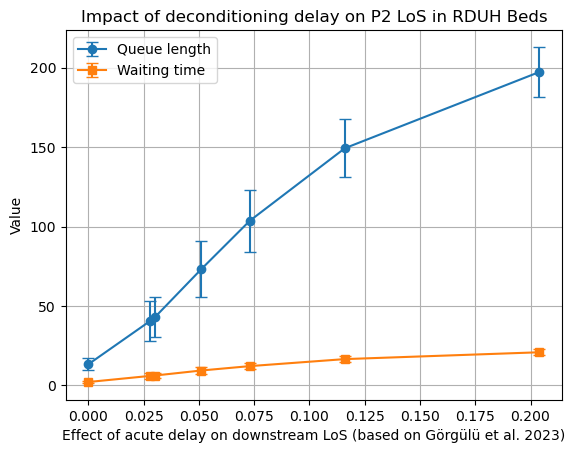

In [14]:
plt.figure()
plt.errorbar(
    df_sensitivity["delay_effect_per_day"],
    df_sensitivity["mean_queue_length"],
    yerr=df_sensitivity["sd_queue_length"],
    marker="o",
    capsize=4,
    label="Queue length"
)
plt.errorbar(
    df_sensitivity["delay_effect_per_day"],
    df_sensitivity["mean_waiting_time"],
    yerr=df_sensitivity["sd_waiting_time"],
    marker="s",
    capsize=4,
    label="Waiting time"
)
plt.xlabel("Effect of acute delay on downstream LoS (based on Görgülü et al. 2023)")
plt.ylabel("Value")
plt.title("Impact of deconditioning delay on P2 LoS in RDUH Beds")
plt.legend()
plt.grid()
plt.show()

## CONCLUSION: 

As the delay - p2 LoS effect increases, queue length explodes,and waiting times increase sharply up to 20 days. The set up has created a reinforcing feedback system. 

Delayed discharge does not just increase LoS, it fundamentally changes system behaviour from stable to unstable. RDUH beds are used first. If patients in these beds are staying longer, they will turn over more slowly. Fewer patient can enter, more will overflow to non-RDUH and block purchase, more patients wait in acute beds, waiting increases across the system. eg. An average 8 day delay with a 5.1% daily increase becomes 1.408 x 24 days (average LoS) = 33.8 days.

It may be that six extra beds aren't enough - or it may be that only some patients are affected and a separate parameter could be used to account for that proportion. 